# Quantum Statistical Potential

The YAML input file can be found at [input_file](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/examples/QSP/input_files/QSP_cgs.yaml) and this notebook at [notebook](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/examples/QSP/QSP_Tutorial.ipynb).

In [ ]:
# Import the usual libraries
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use('MSUstyle')
# Import sarkas
from sarkas.processes import PreProcess

# Create the file path to the YAML input file
input_file_name = os.path.join('input_files',  'QSP_Kelbg.yaml')










 _______  _______  _______  _        _______  _______ 
(  ____ \(  ___  )(  ____ )| \    /\(  ___  )(  ____ \
| (    \/| (   ) || (    )||  \  / /| (   ) || (    \/
| (_____ | (___) || (____)||  (_/ / | (___) || (_____ 
(_____  )|  ___  ||     __)|   _ (  |  ___  |(_____  )
      ) || (   ) || (\ (   |  ( \ \ | (   ) |      ) |
/\____) || )   ( || ) \ \__|  /  \ \| )   ( |/\____) |
\_______)|/     \||/   \__/|_/    \/|/     \|\_______)
                                                      


An open-source pure-python molecular dynamics suite for non-ideal plasmas.




********************************************************************************
                                 Preprocessing                                  
********************************************************************************

Job ID: qsp_cgs
Job directory: SarkasSimulations/qsp_cgs
PreProcessing directory: 
SarkasSimulations/qsp_cgs/PreProcessing

Equilibration dumps directory: 
SarkasSimulatio

PP acceleration timer:   0%|          | 0/11 [00:00<?, ?it/s]

Time of PP acceleration calculation averaged over 10 steps:
0 min 0 sec 126 msec 179 usec 145 nsec 



PM acceleration timer:   0%|          | 0/11 [00:00<?, ?it/s]

Time of PM acceleration calculation averaged over 10 steps:
0 min 0 sec 266 msec 933 usec 775 nsec 



  0%|          | 0/11 [00:00<?, ?it/s]

Time of a single Equilibration step averaged over 10 steps:
0 min 0 sec 390 msec 161 usec 68 nsec 



  0%|          | 0/11 [00:00<?, ?it/s]

Time of a single Production step averaged over 10 steps:
0 min 0 sec 395 msec 681 usec 401 nsec 



----------------------- Total Estimated Times ------------------------ 


Equilibration Time: 0 hrs 26 min 0 sec

Production Time: 0 hrs 13 min 11 sec

Total Run Time: 0 hrs 39 min 12 sec


========================= Filesize Estimates =========================

Equilibration:
	H5MD filesize: 0 GB 497 MB 441 KB 254 bytes

Production:
	H5MD filesize: 0 GB 414 MB 397 KB 273 bytes

Total minimum required space: 0 GB 911 MB 838 KB 527 bytes


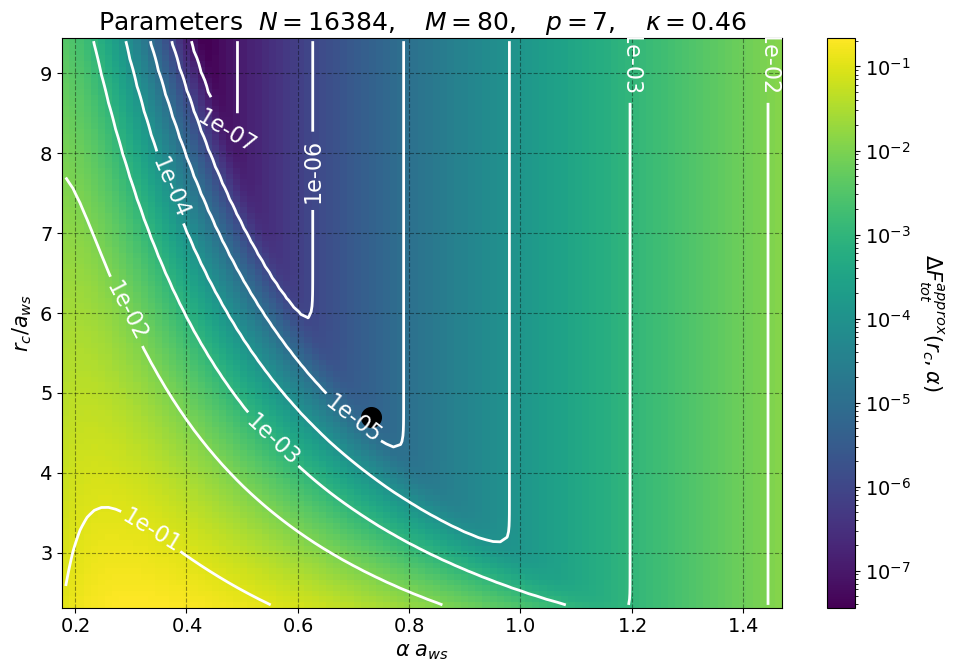

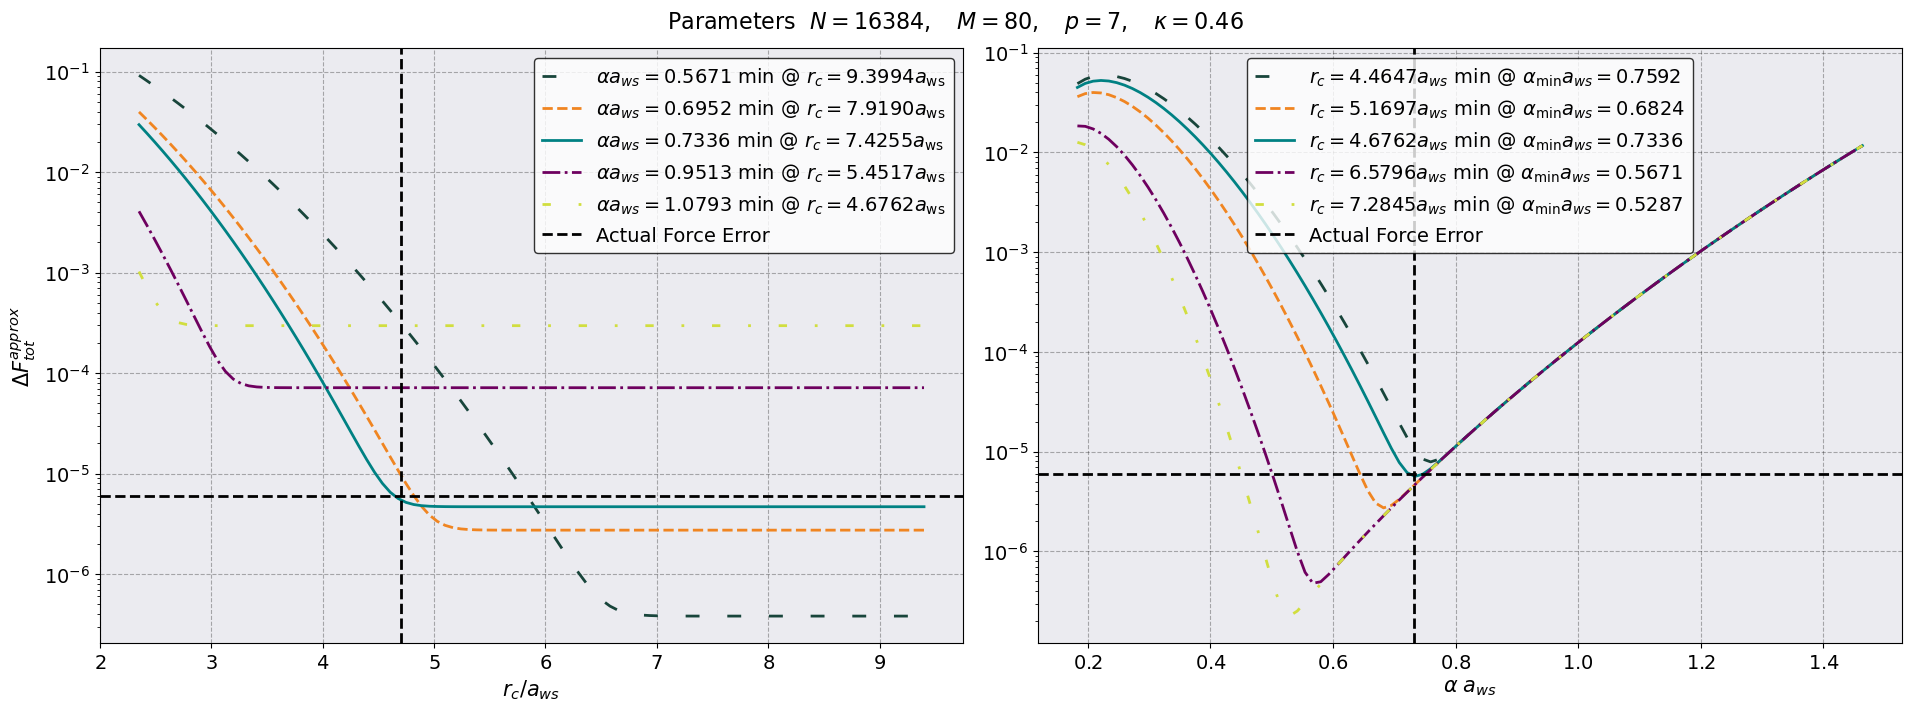

In [ ]:
pre = PreProcess(input_file_name, )
pre.setup(read_yaml=True, )
pre.run(pppm_estimate = False, )

In [6]:
# pp_cells = [3, 4, 5, 6]
pm_meshes = [32, 64, 80, 96, 100, 128, 144, 192, 216, 256]
pm_caos = [3, 4, 5, 6, 7]
fftw_threads = [1, 2, 4, 8]

csv_path = os.path.join(
    pre.io.directory_tree["preprocessing"]["path"],
    f"BayesianPPPM_data_{pre.io.job_id}.csv",
)
results_df, best_point = pre.timing_study_calculation(
    target_error=1e-5,
    # pp_cells=pp_cells,
    pm_meshes=pm_meshes,
    pm_caos=pm_caos,
    method="bayesian",
    warm_start_from = csv_path,
    **{"fftw_thread_options": fftw_threads,
        "n_bo_iterations": 50}
)


Physical bounds:
  r_c          : [1.1689e-08, 1.1725e-07]
  alpha        : [2.0060e+07, 6.4190e+08]
  M            : [32, 64, 80, 96, 100, 128, 144, 192, 216, 256]
  CAO          : [3, 4, 5, 6, 7]
  FFTW threads : [1, 2, 4, 8]

============== Phase 1: Loading previous run ===============
  Source: SarkasSimulations/qsp_cgs/PreProcessing/BayesianPPPM_data_qsp_cgs.csv
  Loaded 15 previous HF points (7 feasible)
  Best feasible time from previous run: 7.2630e-01 s

======= Phase 2: High-fidelity Bayesian Optimization =======
  Budget: 50 MD evaluations
  [  1/50] rc=4.616e-08  alpha=2.0060e+07  M= 32  CAO=3  threads= 8  err=3.15e-03  t=5.8504e-01s  ✗ infeasible
  [  2/50] rc=7.067e-08  alpha=4.6808e+07  M= 32  CAO=3  threads= 4  err=8.48e-04  t=2.3773e+00s  ✗ infeasible
  [  3/50] rc=2.111e-08  alpha=6.4190e+08  M=144  CAO=7  threads= 4  err=8.69e-02  t=6.8654e-01s  ✗ infeasible
  [  4/50] rc=1.169e-08  alpha=5.4578e+08  M= 32  CAO=3  threads= 1  err=7.25e-01  t=5.0489e-02s  ✗ infeasibl

/Users/silves28/anaconda3/envs/sarkas/lib/python3.10/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


  [ 30/50] rc=3.671e-08  alpha=6.1935e+07  M= 64  CAO=6  threads= 8  err=1.48e-03  t=4.4563e-01s  ✗ infeasible
  [ 31/50] rc=3.529e-08  alpha=1.3075e+08  M= 64  CAO=6  threads= 1  err=1.55e-04  t=4.3520e-01s  ✗ infeasible
  [ 32/50] rc=2.430e-08  alpha=1.2783e+08  M= 64  CAO=7  threads= 8  err=6.48e-05  t=3.0232e-01s  ✗ infeasible


/Users/silves28/anaconda3/envs/sarkas/lib/python3.10/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


  [ 33/50] rc=2.960e-08  alpha=9.5218e+07  M= 64  CAO=7  threads= 4  err=1.30e-04  t=3.4867e-01s  ✗ infeasible
  [ 34/50] rc=1.561e-08  alpha=1.1890e+08  M= 64  CAO=6  threads= 8  err=1.71e-02  t=1.8916e-01s  ✗ infeasible
  [ 35/50] rc=3.182e-08  alpha=1.3773e+08  M= 64  CAO=7  threads= 8  err=1.34e-04  t=4.1392e-01s  ✗ infeasible
  [ 36/50] rc=3.306e-08  alpha=9.9983e+07  M= 64  CAO=5  threads= 4  err=5.81e-05  t=3.1780e-01s  ✗ infeasible
  [ 37/50] rc=2.792e-08  alpha=1.1447e+08  M= 64  CAO=5  threads= 2  err=1.47e-04  t=2.4869e-01s  ✗ infeasible
  [ 38/50] rc=3.732e-08  alpha=1.2306e+08  M= 80  CAO=7  threads= 4  err=4.37e-06  t=5.7347e-01s  ✓ FEASIBLE
  [ 39/50] rc=2.401e-08  alpha=1.2060e+08  M= 32  CAO=6  threads= 4  err=1.88e-02  t=1.5493e-01s  ✗ infeasible
  [ 40/50] rc=3.134e-08  alpha=1.2261e+08  M= 80  CAO=7  threads= 4  err=4.21e-06  t=4.4624e-01s  ✓ FEASIBLE
        *** New best: time=4.4624e-01s ***
  [ 41/50] rc=2.747e-08  alpha=1.2285e+08  M= 80  CAO=7  threads= 4  err=

/Users/silves28/anaconda3/envs/sarkas/lib/python3.10/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)
/Users/silves28/anaconda3/envs/sarkas/lib/python3.10/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed on the second try, after generating a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


  [ 47/50] rc=2.741e-08  alpha=1.2461e+08  M= 80  CAO=6  threads= 1  err=1.68e-05  t=3.5578e-01s  ✗ infeasible
  [ 48/50] rc=2.750e-08  alpha=1.2627e+08  M= 80  CAO=6  threads= 8  err=1.85e-05  t=3.3906e-01s  ✗ infeasible
  [ 49/50] rc=1.173e-07  alpha=6.4190e+08  M=144  CAO=7  threads= 8  err=8.69e-02  t=9.5390e+00s  ✗ infeasible


/Users/silves28/anaconda3/envs/sarkas/lib/python3.10/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


  [ 50/50] rc=1.169e-08  alpha=3.9925e+08  M= 32  CAO=5  threads= 2  err=4.65e-01  t=7.6268e-02s  ✗ infeasible

================== Optimization Complete ===================
  Best feasible configuration:
    rc=2.7468e-08  alpha=1.2285e+08  M=80  CAO=7  threads=4
    force_error=6.3032e-06  time=3.8795e-01s

  Alpha refinement: 1.228504e+08 → 1.252040e+08  (analytical error 6.30e-06 → 5.45e-06)

BO results saved to: SarkasSimulations/qsp_cgs/PreProcessing/BayesianPPPM_data_qsp_cgs.csv

OPTIMAL PPPM CONFIGURATION (BAYESIAN):
  Mesh: 80 | CAO: 7 | rc: 2.746767e-08
  Ewald alpha: 1.252040e+08 | FFTW threads: 4
  Force Error: 5.968418e-06 | Total Time: 3.921590e-01 s


In [28]:
import pandas as pd
from pyparsing import Optional
from os.path import join

def compute_pareto_front(
    results_df: pd.DataFrame,
    fidelity: str = "high",
) -> pd.DataFrame:
    """
    Compute the Pareto front in (force_error, time) space.

    A point is Pareto-optimal if no other point has both smaller time
    AND smaller force_error.

    Parameters
    ----------
    results_df : DataFrame from _bayesian_parameter_selection
    fidelity   : 'high', 'analytical', or 'all'

    Returns
    -------
    DataFrame of Pareto-optimal rows, sorted by force_error ascending.
    """
    df = results_df.copy() if fidelity == "all" else results_df[
        results_df["fidelity"] == fidelity
    ].copy()

    if df.empty:
        return df

    times = df["time"].values
    errors = df["force_error"].values
    n = len(df)

    # Vectorised Pareto dominance check using broadcasting.
    # dominated[i] = True if any j strictly dominates i.
    t_col = times.reshape(1, n)   # (1, n)
    e_col = errors.reshape(1, n)  # (1, n)
    t_row = times.reshape(n, 1)   # (n, 1)
    e_row = errors.reshape(n, 1)  # (n, 1)

    # j dominates i when t_col[j] <= t_row[i] and e_col[j] <= e_row[i]
    # with at least one strict inequality.
    strict_t = t_col < t_row   # (n, n): j strictly better in time
    strict_e = e_col < e_row   # (n, n): j strictly better in error
    weak_t = t_col <= t_row
    weak_e = e_col <= e_row

    # dominated[i] is True if any j != i strictly dominates i.
    # Self-dominance is impossible by construction: the strict inequality
    # in at least one objective is never satisfied when i == j, so the
    # diagonal of the (n, n) matrix is always False before the reduction.
    # No post-reduction correction is needed.
    dominated = ((weak_t & strict_e) | (strict_t & weak_e)).any(axis=1)

    pareto_df = df[~dominated].sort_values("force_error").reset_index(drop=True)
    return pareto_df

def plot_bo_results(
        self,
        results_df: pd.DataFrame,
        target_error: float,
        save_dir: str = None,
        show_plots: bool = False,
    ):
        """
        Generate diagnostic plots for the BO run.
 
        Figures produced:
            1. Pareto front (force_error vs time)
            2. BO convergence curve (best feasible time vs iteration)
            3. Parameter scatter — rc vs alpha, M vs CAO, and thread count histogram
        """
        try:
            import matplotlib.pyplot as plt
        except ImportError:
            print("matplotlib not available — skipping plots.")
            return
 
        if save_dir is None:
            save_dir = getattr(self, "pppm_plots_dir", ".")
 
        an = results_df[results_df["fidelity"] == "analytical"]
        hf = results_df[results_df["fidelity"] == "high"]
        hf_feas = hf[hf["feasible"]]
        hf_infeas = hf[~hf["feasible"]]
 
        # ---- Figure 1: Pareto front ------------------------------------
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(an["force_error"], an["time"] * 1e3,
                   c="lightblue", alpha=0.3, s=10, label="Analytical warm-start")
        ax.scatter(hf_infeas["force_error"], hf_infeas["time"] * 1e3,
                   c="salmon", alpha=0.7, s=40, marker="x", label="HF infeasible")
        ax.scatter(hf_feas["force_error"], hf_feas["time"] * 1e3,
                   c="green", alpha=0.9, s=60, marker="o", label="HF feasible")
 
        pareto = compute_pareto_front(results_df, fidelity="high")
        if not pareto.empty:
            ax.plot(pareto["force_error"], pareto["time"] * 1e3,
                    "k--", linewidth=1.5, label="Pareto front (HF)")
 
        ax.axvline(target_error, color="red", linestyle=":", linewidth=1.5,
                   label=f"Target error = {target_error:.0e}")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Force error", fontsize=12)
        ax.set_ylabel("Time per step (ms)", fontsize=12)
        ax.set_title("PPPM Pareto Front — BO Results", fontsize=13)
        ax.legend(fontsize=9)
        fig.tight_layout()
        fig.savefig(join(save_dir, "BO_pareto_front.png"), dpi=150)
        plt.show() if show_plots else plt.close(fig)
 
        # ---- Figure 2: Convergence curve --------------------------------
        summary = self.bo_convergence_summary(results_df, target_error)
        if summary["improvement_curve"]:
            iters, best_times = zip(*summary["improvement_curve"])
            fig, ax = plt.subplots(figsize=(7, 4))
            ax.step(iters, [t * 1e3 for t in best_times], where="post",
                    color="steelblue", linewidth=2)
            ax.set_xlabel("BO iteration (high-fidelity)", fontsize=12)
            ax.set_ylabel("Best feasible time (ms)", fontsize=12)
            ax.set_title("BO Convergence", fontsize=13)
            if summary["first_feasible_iter"] is not None:
                ax.axvline(summary["first_feasible_iter"], color="green", linestyle="--",
                           label=f"First feasible (iter {summary['first_feasible_iter']})")
                ax.legend(fontsize=9)
            fig.tight_layout()
            fig.savefig(join(save_dir, "BO_convergence.png"), dpi=150)
            plt.show() if show_plots else plt.close(fig)
 
        # ---- Figure 3: Parameter scatter --------------------------------
        if not hf.empty:
            fig, axes = plt.subplots(1, 3, figsize=(19, 5))
 
            edge_colors = ["green" if f else "red" for f in hf["feasible"]]
            sc = axes[0].scatter(
                hf["rc"] / self.parameters.a_ws, hf["alpha"] * self.parameters.a_ws,
                c=hf["M"], cmap="tab10", s=160, alpha=0.8,
                edgecolors=edge_colors, linewidths=1.5,
            )
            plt.colorbar(sc, ax=axes[0], label="Mesh size M",)
            axes[0].set_xlabel(r"$r_c / a_{ws}$", fontsize=12)
            axes[0].set_ylabel(r"$\alpha \cdot a_{ws}$", fontsize=12)
            axes[0].set_title("HF evaluations (colour = M)", fontsize=12)
 
            sc2 = axes[1].scatter(
                hf["M"], hf["cao"],
                c=hf["time"] * 1e3, cmap="plasma", s=80, alpha=0.8, edgecolors=edge_colors, linewidths=1.5
            )
            plt.colorbar(sc2, ax=axes[1], label="Time (ms)")
            axes[1].set_xlabel("Mesh size M", fontsize=12)
            axes[1].set_ylabel("CAO (B-spline order)", fontsize=12)
            axes[1].set_title("HF evaluations (colour = time)", fontsize=12)
 
            if "fftw_threads" in hf.columns:
                thread_counts = sorted(hf["fftw_threads"].unique())
                thread_times = [
                    hf.loc[hf["fftw_threads"] == t, "time"].mean() * 1e3
                    for t in thread_counts
                ]
                axes[2].bar([str(t) for t in thread_counts], thread_times,
                            color="steelblue", alpha=0.8)
                axes[2].set_xlabel("FFTW threads", fontsize=12)
                axes[2].set_ylabel("Mean time (ms)", fontsize=12)
                axes[2].set_title("Mean step time by thread count", fontsize=12)
 
            fig.tight_layout()
            fig.savefig(join(save_dir, "BO_parameter_scatter.png"), dpi=150)
            plt.show() if show_plots else plt.close(fig)
 
        if self.parameters.verbose:
            print(f"\nPlots saved to: {save_dir}")

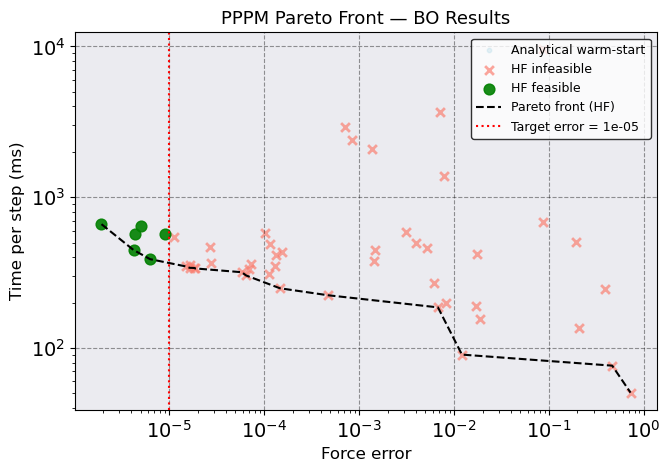

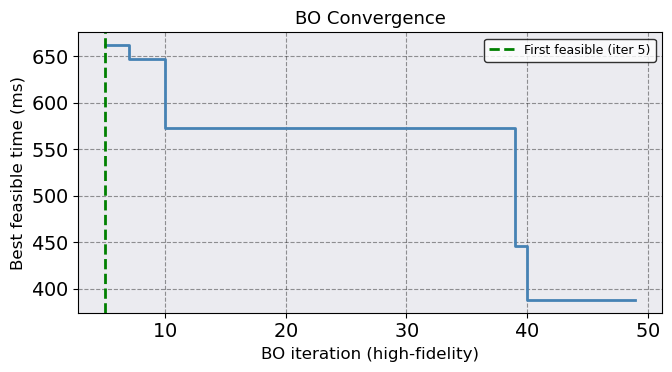

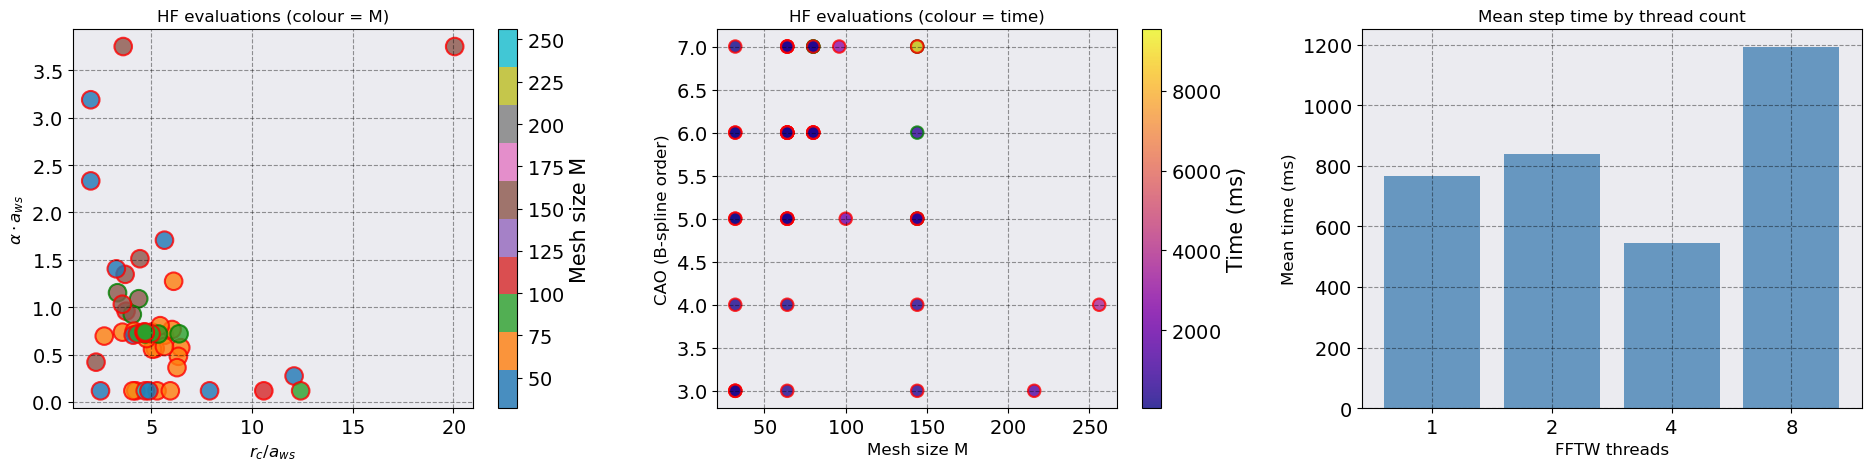


Plots saved to: SarkasSimulations/qsp_cgs/PreProcessing/PPPM_Plots


In [29]:
plot_bo_results(pre, results_df, target_error=1e-5, show_plots=True)

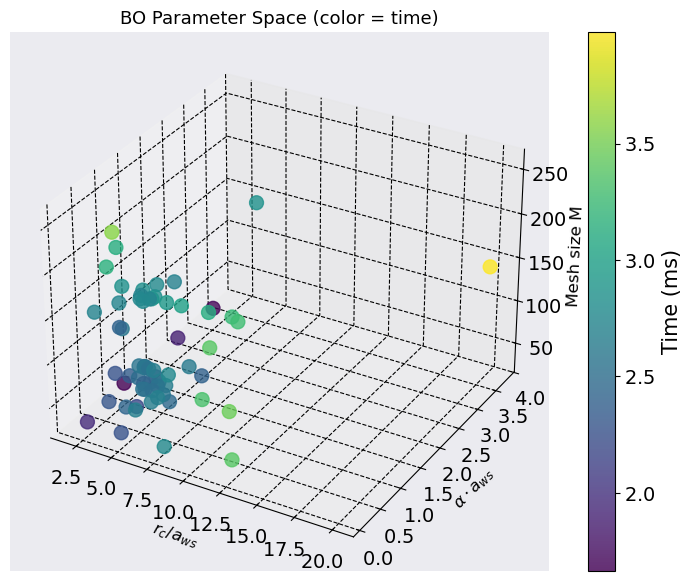

In [35]:
import matplotlib as mpl
results_df.head()

# 3D scatter plot of rc, alpha, and M colored by time
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    results_df["rc"] / pre.parameters.a_ws,
    results_df["alpha"] * pre.parameters.a_ws,
    results_df["M"],
    c=np.log10(results_df["time"] * 1e3), cmap="viridis", s=100, alpha=0.8
)
plt.colorbar(sc, ax=ax, label="Time (ms)",)
ax.set_xlabel(r"$r_c / a_{ws}$", fontsize=12)
ax.set_ylabel(r"$\alpha \cdot a_{ws}$", fontsize=12)
ax.set_zlabel("Mesh size M", fontsize=12)
ax.set_title("BO Parameter Space (color = time)", fontsize=13)
plt.show()

In [ ]:
# pre.run(pppm_estimate=True)
from sarkas.pppm_bayesian_optimization import compute_physical_bounds, FFT_FRIENDLY_MESHES

a_ws = pre.potential.a_ws
box_length = pre.potential.box_lengths.min()
N = pre.potential.total_num_ptcls

In [ ]:
pp_cells = [3, 4, 5, 6]
pm_meshes = [32, 64, 80, 90, 100, 128,]
pm_caos = [4, 5, 6, 7]

rescaling_constant = pre.potential.QFactor * np.sqrt(3.0/(4.0 * np.pi)) / pre.potential.matrix[0,0,0]
rescaling_constant /= pre.potential.total_num_ptcls 


# --- Resolve mesh and CAO option lists --------------------------
mesh_options = list(pm_meshes) #if pm_meshes is not None else FFT_FRIENDLY_MESHES
cao_list     = list(pm_caos)   # if pm_caos   is not None else CAO_OPTIONS

# --- Derive rc bounds from pp_cells if provided -----------------
# pp_cells is the number of cells along one dimension, so
# rc = box_length / pp_cells.  Larger cell count => smaller rc.
rc_min_override = None
rc_max_override = None
if pp_cells is not None and len(pp_cells) > 0:
    pp_cells_arr = np.asarray(pp_cells, dtype=float)
    # box_length here is already dimensionless (L / a_ws)
    rc_min_override = box_length / float(pp_cells_arr.max())
    rc_max_override = box_length / float(pp_cells_arr.min())

# compute_physical_bounds receives dimensionless a_ws=1 and
# dimensionless box_length = L/a_ws, giving rc bounds in units of a_ws.
bounds = compute_physical_bounds(
    a_ws,
    box_length,
    mesh_options,
    cao_options=cao_list,
    rc_min_override=rc_min_override,
    rc_max_override=rc_max_override,
)

if pre.parameters.verbose:
    print(f"\nPhysical bounds:")
    print(f"  r_c   : [{bounds['rc_min']:.4e}, {bounds['rc_max']:.4e}]")
    print(f"  alpha : [{bounds['alpha_min']:.4e}, {bounds['alpha_max']:.4e}]")
    print(f"  M     : {bounds['M_options']}")
    print(f"  CAO   : {bounds['cao_options']}")


In [ ]:
from sarkas.pppm_bayesian_optimization import PPPMParameterCodec, make_analytical_error_fn, make_analytical_time_fn

codec = PPPMParameterCodec(bounds)

# Build analytical model closures.
# Note: a_ws is passed as the second argument so that the function
# can convert rc and alpha to the dimensionless units expected by
# the Sarkas force error routines (rc/a_ws, alpha*a_ws, etc.).
analytical_error_fn = make_analytical_error_fn(
    a_ws,
    pre.potential.screening_length,
    rescaling_constant,
    box_length,
)
analytical_time_fn = make_analytical_time_fn(N, box_length)

# Build high-fidelity evaluator (actual timing calls)
evaluate_fn = pre._make_hf_evaluator(rescaling_constant)


In [ ]:
from sarkas.pppm_bayesian_optimization import analytical_warm_start
n_warm_rc = 10
n_warm_alpha = 10

X_warm, Y_time_warm, Y_error_warm = analytical_warm_start(
            codec, analytical_error_fn, analytical_time_fn, n_warm_rc, n_warm_alpha
        )

records = []
target_error = 1e-5

for i in range(X_warm.shape[0]):
    rc, alpha, M, cao = codec.decode(X_warm[i])
    records.append({
        "rc":          rc,
        "alpha":       alpha,
        "M":           M,
        "cao":         cao,
        "time":        float(Y_time_warm[i]),
        "force_error": float(Y_error_warm[i]),
        "fidelity":    "analytical",
        "feasible":    float(Y_error_warm[i]) <= target_error,
    })

if pre.parameters.verbose:
    n_feasible_warm = sum(1 for r in records if r["feasible"])
    print(f"  Feasible analytical points: {n_feasible_warm} / {len(records)}")


In [ ]:
from sarkas.pppm_bayesian_optimization import build_surrogate

# Initialise surrogates from analytical data.
# Negate time so the objective GP is maximised (BoTorch maximises EI).
Y_time_neg = -Y_time_warm  # shape (n, 1)

obj_model  = build_surrogate(X_warm, Y_time_neg,   codec.cat_dims)
con_model  = build_surrogate(X_warm, Y_error_warm, codec.cat_dims)


In [ ]:
import torch

# Short-hands
bounds = codec.botorch_bounds  # shape (2, d)

# ── fine grid in normalised [0,1] space ────────────────────────────────────
Nr, Na = n_warm_rc * 10, n_warm_alpha * 10
rc_grid    = torch.linspace(bounds[0, 0], bounds[1, 0], Nr,    dtype=torch.double)
alpha_grid = torch.linspace(bounds[0, 1], bounds[1, 1], Na,    dtype=torch.double)
RC, ALPHA  = torch.meshgrid(rc_grid, alpha_grid, indexing='ij')  # (Nr, Na)
 
rc_flat    = RC.reshape(-1)
alpha_flat = ALPHA.reshape(-1)
 
# Fix one (M, cao) combination — index 1 = second mesh option, index 2 = third cao option.
# Change these to whichever categorical combination you want to inspect.
M_idx   = 1   # index into codec.M_options
cao_idx = 2   # index into codec.cao_options
M_fixed   = torch.full_like(rc_flat, float(M_idx))
cao_fixed = torch.full_like(rc_flat, float(cao_idx))
 
X_plot = torch.stack([rc_flat, alpha_flat, M_fixed, cao_fixed], dim=1)  # (Nr*Na, 4)
 

In [ ]:
# ── predict in ORIGINAL scale via .posterior() ────────────────────────────
# model.posterior() applies the inverse outcome transform (un-standardises),
# so the mean is in the same units as the training targets.
with torch.no_grad():
    # Force error surrogate — values should be positive
    error_mean = con_model.posterior(X_plot).mean.squeeze()      # (Nr*Na,)
 
    # Time surrogate — targets were negated, so negate back to get positive times
    time_mean  = -obj_model.posterior(X_plot).mean.squeeze()     # (Nr*Na,)
 
error_2d = error_mean.reshape(Nr, Na).numpy()
time_2d  = time_mean.reshape(Nr, Na).numpy()
 

In [ ]:
# ── decode normalised rc/alpha back to physical units for axis labels ──────
# RC and ALPHA are in normalised [0,1]; decode a single row/column is enough.
rc_phys    = RC[:, 0].numpy()    * (codec.rc_max    - codec.rc_min)    + codec.rc_min
alpha_phys = ALPHA[0, :].numpy() * (codec.alpha_max - codec.alpha_min) + codec.alpha_min
 
# Convert to the units your plot wants (divide rc by a_ws, multiply alpha by a_ws)
rc_ax    = rc_phys    / a_ws   # rc in units of a_ws (dimensionless)
alpha_ax = alpha_phys * a_ws   # alpha in units of 1/a_ws (dimensionless)
 
M_val   = codec.M_options[M_idx]
cao_val = codec.cao_options[cao_idx]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(19, 6))
 
for ax, data, label, fmt in [
    (axes[0], error_2d, r"Surrogate force error",  "%1.0e"),
    (axes[1], time_2d,  r"Surrogate time (s)", "%1.2e"),
]:
    CS  = ax.pcolormesh(alpha_ax, rc_ax, data, shading='auto')
    CS2 = ax.contour(alpha_ax, rc_ax,  data, levels=10, colors='w', linewidths=0.5)
    ax.clabel(CS2, fmt=fmt, colors='w')
    fig.colorbar(CS, ax=ax).set_label(label, va='bottom', rotation=270, labelpad=15)
    ax.set_ylabel(r"$r_c / a_{\rm ws}$")
    ax.set_xlabel(r"$\alpha \cdot a_{\rm ws}$")
    ax.set_title(f"M={M_val}, CAO={cao_val}")
 
# ── also scatter the actual warm-start points for this (M, cao) slice ─────
mask = (X_warm[:, 2] == M_idx) & (X_warm[:, 3] == cao_idx)
if mask.any():
    rc_w    = X_warm[mask, 0].numpy() * (codec.rc_max - codec.rc_min) + codec.rc_min
    alpha_w = X_warm[mask, 1].numpy() * (codec.alpha_max - codec.alpha_min) + codec.alpha_min
    axes[0].scatter(alpha_w * a_ws, rc_w / a_ws,  c='r', s=20, zorder=5, label='warm-start pts')
    axes[0].legend(fontsize=8)
    axes[1].scatter(alpha_w * a_ws, rc_w / a_ws,  c='r', s=20, zorder=5, label='warm-start pts')
    axes[1].legend(fontsize=8)
 
fig.suptitle(
    f"Surrogate predictions — M={M_val}, CAO={cao_val}",
    fontsize=11,
)
fig.tight_layout()

Ok. The surrogate seems good enough. It is order of magnitude off, but at least is structure resembles the expected one. 

Let's now run the BO

In [ ]:
from sarkas.pppm_bayesian_optimization import build_constrained_acqf
from botorch.optim import optimize_acqf_mixed 

# Track high-fidelity observations separately for surrogate updates
X_hf     = torch.empty((0, codec.n_dims), dtype=torch.double)
Y_time_hf  = torch.empty((0, 1),            dtype=torch.double)
Y_error_hf = torch.empty((0, 1),            dtype=torch.double)

# Surrogate is trained on log10(error) and log10(time), so the
# feasibility threshold must also be in log10 space.
log_target_error = np.log10(target_error)

best_feasible_time  = float("inf")
best_feasible_point = None

bounds = codec.botorch_bounds
fixed_features = codec.fixed_features_list()

n_bo_iterations = 20
n_restarts = 10
raw_samples = 256

# ---- Build acquisition function --------------------------------
# best_f: best negated time among points the GP believes are feasible
# We approximate feasibility using the constraint GP's posterior mean.
with torch.no_grad():
    # Evaluate constraint GP mean over all warm + HF inputs
    X_all_so_far = torch.cat([X_warm, X_hf], dim=0) if X_hf.shape[0] > 0 else X_warm
    con_post = con_model.posterior(X_all_so_far)
    con_mean = con_post.mean.squeeze()  # (n,)

    feasible_mask = con_mean <= log_target_error
    if feasible_mask.any():
        obj_mean = obj_model.posterior(X_all_so_far).mean.squeeze()
        best_f = float(obj_mean[feasible_mask].max())
    else:
        best_f = float(obj_model.posterior(X_all_so_far).mean.max())

acqf = build_constrained_acqf(obj_model, con_model, best_f, log_target_error)

# ---- Optimise acquisition over mixed space ----------------------

candidate, acq_value = optimize_acqf_mixed(
    acq_function=acqf,
    bounds=bounds,
    fixed_features_list=fixed_features,
    q=1,
    num_restarts=n_restarts,
    raw_samples=raw_samples,
    )

# ---- Decode and evaluate ---------------------------------------
rc, alpha, M, cao = codec.decode(candidate)
rc    = np.clip(rc,    codec.rc_min,    codec.rc_max)
alpha = np.clip(alpha, codec.alpha_min, codec.alpha_max)

print(f"candidate: rc: {rc:.4e}, alpha: {alpha:.4e}, M: {M}, CAO: {cao} — acq_value: {acq_value:.4e}")

In [ ]:
time_val, error_val = evaluate_fn(rc, alpha, M, cao)

In [ ]:
from typing import Dict


def _refine_alpha(
    self,
    best_point: Dict,
    analytical_error_fn,
    target_error: float,
    n_grid: int = 200,
) -> Dict:
    """
    Given a feasible (rc, M, cao) from the BO, find the alpha that
    minimises the analytical force error subject to the error staying
    below target_error.

    Why this is valid
    -----------------
    PP cost  ~ (4/3)π(rc/L)³ N  — depends only on rc, not alpha.
    PM cost  ~ M³ log M³        — depends only on M, not alpha.
    Charge assignment cost ~ cao³ N — depends only on cao, not alpha.

    So at fixed (rc, M, cao) the total step time is constant as alpha
    varies.  The force error as a function of alpha has a single minimum
    (the valley visible in image 1) where both the PP and PM errors are
    balanced.  We find that minimum with a dense 1-D grid on the
    analytical model — no MD timing calls are needed.

    Parameters
    ----------
    best_point         : dict from _extract_best_point with keys
                            rc, alpha, M, cao, time, force_error
    analytical_error_fn: cheap analytical error closure
    target_error       : feasibility threshold (kept for safety check)
    n_grid             : number of alpha values to evaluate on the grid

    Returns
    -------
    Updated best_point dict with refined alpha and force_error.
    The time entry is unchanged (alpha does not affect timing).
    """
    from scipy.optimize import minimize_scalar

    rc  = best_point["rc"]
    M   = best_point["M"]
    cao = best_point["cao"]

    # Search over the full alpha range known to the codec
    alpha_lo = self._bo_codec.alpha_min
    alpha_hi = self._bo_codec.alpha_max

    # 1-D grid to find a good bracket (analytical fn may be non-convex
    # at the extremes due to the PM error rising steeply at large alpha)
    alpha_grid = np.linspace(alpha_lo, alpha_hi, n_grid)
    errors = np.array([analytical_error_fn(rc, a, M, cao) for a in alpha_grid])

    # Find the global minimum on the grid
    best_idx   = int(np.argmin(errors))
    best_alpha = float(alpha_grid[best_idx])
    best_err   = float(errors[best_idx])

    # Refine with scalar minimisation in a bracket around the grid minimum
    bracket_lo = alpha_grid[max(0,          best_idx - 5)]
    bracket_hi = alpha_grid[min(n_grid - 1, best_idx + 5)]

    try:
        result = minimize_scalar(
            lambda a: analytical_error_fn(rc, float(a), M, cao),
            bounds=(bracket_lo, bracket_hi),
            method="bounded",
            options={"xatol": 1e-6},
        )
        if result.fun < best_err:
            best_alpha = float(result.x)
            best_err   = float(result.fun)
    except Exception:
        pass  # fall back to grid result

    # Only update if the refined alpha actually improves the error.
    # If the minimum of the analytical model is above target_error
    # (can happen if the model is inaccurate) keep the BO result.
    if best_err < best_point["force_error"]:
        if self.parameters.verbose:
            print(
                f"\n  Alpha refinement: {best_point['alpha']:.4f} → {best_alpha:.4f}"
                f"  (error {best_point['force_error']:.2e} → {best_err:.2e})"
            )
        updated = dict(best_point)
        updated["alpha"]       = best_alpha
        updated["force_error"] = best_err
        # Store the codec so the plot helper can access alpha bounds
        return updated

    return best_point

In [ ]:

for iteration in range(n_bo_iterations):

    # ---- Build acquisition function --------------------------------
    # best_f: best negated time among points the GP believes are feasible
    # We approximate feasibility using the constraint GP's posterior mean.
    with torch.no_grad():
        # Evaluate constraint GP mean over all warm + HF inputs
        X_all_so_far = torch.cat([X_warm, X_hf], dim=0) if X_hf.shape[0] > 0 else X_warm
        con_post = con_model.posterior(X_all_so_far)
        con_mean = con_post.mean.squeeze()  # (n,)

        feasible_mask = con_mean <= log_target_error
        if feasible_mask.any():
            obj_mean = obj_model.posterior(X_all_so_far).mean.squeeze()
            best_f = float(obj_mean[feasible_mask].max())
        else:
            best_f = float(obj_model.posterior(X_all_so_far).mean.max())

    acqf = build_constrained_acqf(obj_model, con_model, best_f, log_target_error)

    # ---- Optimise acquisition over mixed space ----------------------
    try:
        candidate, acq_value = optimize_acqf_mixed(
            acq_function=acqf,
            bounds=bounds,
            fixed_features_list=fixed_features,
            q=1,
            num_restarts=n_restarts,
            raw_samples=raw_samples,
        )
    except Exception as e:
        if pre.parameters.verbose:
            print(f"  [iter {iteration+1}] Acquisition optimisation failed: {e}")
            print("  Falling back to random candidate.")
        candidate = torch.rand(1, codec.n_dims, dtype=torch.double)
        candidate[0, 2] = float(np.random.randint(0, len(codec.M_options)))
        candidate[0, 3] = float(np.random.randint(0, len(codec.cao_options)))
        candidate = candidate * (bounds[1] - bounds[0]) + bounds[0]

    # ---- Decode and evaluate ---------------------------------------
    rc, alpha, M, cao = codec.decode(candidate)
    rc    = np.clip(rc,    codec.rc_min,    codec.rc_max)
    alpha = np.clip(alpha, codec.alpha_min, codec.alpha_max)

    try:
        time_val, error_val = evaluate_fn(rc, alpha, M, cao)
    except Exception as e:
        if pre.parameters.verbose:
            print(f"  [iter {iteration+1}] MD evaluation failed: {e}. Skipping.")
        continue

    feasible = error_val <= target_error

    if pre.parameters.verbose:
        status = "✓ FEASIBLE" if feasible else "✗ infeasible"
        print(
            f"  [{iteration+1:3d}/{n_bo_iterations}] "
            f"rc={rc:.3e}  α={alpha:.4e}  M={M:3d}  cao={cao}  "
            f"err={error_val:.2e}  t={time_val:.4e}s  {status}"
        )

    if feasible and time_val < best_feasible_time:
        best_feasible_time  = time_val
        best_feasible_point = {"rc": rc, "alpha": alpha, "M": M, "cao": cao,
                                "time": time_val, "force_error": error_val}
        if pre.parameters.verbose:
            print(f"        *** New best: time={time_val:.4e}s ***")

    records.append({
        "rc":          rc,
        "alpha":       alpha,
        "M":           M,
        "cao":         cao,
        "time":        time_val,
        "force_error": error_val,
        "fidelity":    "high",
        "feasible":    feasible,
    })

    # ---- Update surrogates — store HF observations in log space ----
    x_new        = codec.encode(rc, alpha, M, cao)
    log_time_new = np.log10(max(time_val,  1e-30))
    log_err_new  = np.log10(max(error_val, 1e-30))
    y_time_new  = torch.tensor([[-log_time_new]], dtype=torch.double)  # negated log
    y_error_new = torch.tensor([[log_err_new]],   dtype=torch.double)

    X_hf       = torch.cat([X_hf,       x_new],        dim=0)
    Y_time_hf  = torch.cat([Y_time_hf,  y_time_new],   dim=0)
    Y_error_hf = torch.cat([Y_error_hf, y_error_new],  dim=0)

    # Rebuild surrogates using ALL data (warm + HF)
    X_all      = torch.cat([X_warm,      X_hf],       dim=0)
    Y_time_all = torch.cat([Y_time_neg,  Y_time_hf],  dim=0)
    Y_err_all  = torch.cat([Y_error_warm, Y_error_hf], dim=0)

    try:
        obj_model = build_surrogate(X_all, Y_time_all,  codec.cat_dims)
        con_model = build_surrogate(X_all, Y_err_all,   codec.cat_dims)
    except Exception as e:
        if pre.parameters.verbose:
            print(f"  [iter {iteration+1}] Surrogate refit failed: {e}. Keeping old model.")

# ------------------------------------------------------------------
# Summary
# ------------------------------------------------------------------
if pre.parameters.verbose:
    print("\n" + " Optimization Complete ".center(60, "="))
    if best_feasible_point:
        p = best_feasible_point
        print(
            f"  Best feasible configuration:\n"
            f"    rc={p['rc']:.4e}  alpha={p['alpha']:.4e}  "
            f"M={p['M']}  cao={p['cao']}\n"
            f"    force_error={p['force_error']:.4e}  time={p['time']:.4e}s"
        )
    else:
        print("  No feasible configuration found within budget.")
        print("  Consider increasing target_error or n_bo_iterations.")



In [ ]:
import pandas as pd

df = pd.DataFrame(records)

In [ ]:
# Find the best feasible high-fidelity point
best_point = pre._extract_best_point(df, target_error)

msg = (
        f"\nOPTIMAL PPPM CONFIGURATION (BAYESIAN):\n"
        f"  Mesh: {best_point['M']} | CAO: {best_point['cao']} "
        f"| rc: {best_point['rc']:.4e}\n"
        f"  Ewald alpha: {best_point['alpha']:.4e} "
        f"| Force Error: {best_point['force_error']:.4e}\n"
        f"  Total Time: {best_point['time']:.4e} s"
    )

print(msg)

In [ ]:
pre.plot_bo_results(df, target_error)

In [ ]:
from scipy.optimize import minimize_scalar

rc  = best_point["rc"]
M   = best_point["M"]
cao = best_point["cao"]

# Search over the full alpha range known to the codec
alpha_lo = codec.alpha_min
alpha_hi = codec.alpha_max

# 1-D grid to find a good bracket (analytical fn may be non-convex
# at the extremes due to the PM error rising steeply at large alpha)
n_grid = 200
alpha_grid = np.linspace(alpha_lo, alpha_hi, n_grid)
errors = np.array([analytical_error_fn(rc, a, M, cao) for a in alpha_grid])

# Find the global minimum on the grid
best_idx   = int(np.argmin(errors))
best_alpha = float(alpha_grid[best_idx])
best_err   = float(errors[best_idx])

 # Refine with scalar minimisation in a bracket around the grid minimum
bracket_lo = alpha_grid[max(0,          best_idx - 5)]
bracket_hi = alpha_grid[min(n_grid - 1, best_idx + 5)]

try:
    result = minimize_scalar(
        lambda a: analytical_error_fn(rc, float(a), M, cao),
        bounds=(bracket_lo, bracket_hi),
        method="bounded",
        options={"xatol": 1e-6},
    )
    if result.fun < best_err:
        best_alpha = float(result.x)
        best_err   = float(result.fun)
except Exception:
    pass  # fall back to grid result

# Only update if the refined alpha actually improves the error.
# If the minimum of the analytical model is above target_error
# (can happen if the model is inaccurate) keep the BO result.
if best_err < best_point["force_error"]:
    if pre.parameters.verbose:
        print(
            f"\n  Alpha refinement: {best_point['alpha']:.4e} → {best_alpha:.4e}"
            f"  (error {best_point['force_error']:.2e} → {best_err:.2e})"
        )
    updated = dict(best_point)
    updated["alpha"]       = best_alpha
    updated["force_error"] = best_err
    # Store the codec so the plot helper can access alpha bounds

best_point = updated


In [ ]:
msg = (
    f"\nOPTIMAL PPPM CONFIGURATION (BAYESIAN):\n"
    f"  Mesh: {best_point['M']} | CAO: {best_point['cao']} "
    f"| rc: {best_point['rc']:.6e}\n"
    f"  Ewald alpha: {best_point['alpha']:.6e} "
    f"| Force Error: {best_point['force_error']:.6e}\n"
    f"  Total Time: {best_point['time']:.6e} s"
)
print(msg)

In [ ]:
csv_path = os.path.join(
    pre.io.directory_tree["preprocessing"]["path"],
    f"BayesianPPPM_data_{pre.io.job_id}.csv",
)
df.to_csv(csv_path, index=False)
msg = f"\nBO results saved to: {csv_path}"
pre.io.write_to_logger(msg)
if pre.parameters.verbose:
    print(msg)

In [ ]:
pp_cells = [3, 4, 5, 6]
pm_meshes = [32, 64, 80, 90, 100, 128,]
pm_caos = [4, 5, 6, 7]

csv_path = os.path.join(
    pre.io.directory_tree["preprocessing"]["path"],
    f"BayesianPPPM_data_{pre.io.job_id}.csv",
)
results_df, best_point = pre.timing_study_calculation(
    target_error=1e-5,
    pp_cells=pp_cells,
    pm_meshes=pm_meshes,
    pm_caos=pm_caos,
    method="bayesian",
    warm_start_from = csv_path,
    **{"n_bo_iterations": 10}
)

In [ ]:
pre.plot_bo_results(results_df, target_error=1e-5)

In [ ]:
pareto_points, best_point = pre.find_pareto_optimal_configs(target_error=1e-6)

In [ ]:
postproc = PostProcess(input_file_name)
postproc.setup(read_yaml=True)

In [ ]:
# Equilibration check
from sarkas.tools.observables import Thermodynamics

therm = Thermodynamics()
therm.setup(postproc.parameters, phase = "equilibration")
therm.temp_energy_plot(postproc, )

In [ ]:
# Production check
therm = Thermodynamics()
therm.setup(postproc.parameters)
therm.temp_energy_plot(postproc)

In [ ]:
# Radial Distribution Function 
from sarkas.tools.observables import RadialDistributionFunction

rdf = RadialDistributionFunction()
rdf.setup(postproc.parameters)
rdf.compute()
# Grab HNC data for comparison
# hnc_r, hnc_gee, hnc_gei, hnc_gii = np.loadtxt('hnc_gall.out', unpack=True)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,7))
# ax.plot(hnc_r , hnc_gee, label = 'hnc e-e RDF')
# ax.plot(hnc_r , hnc_gei, label = 'hnc e-p RDF')
# ax.plot(hnc_r , hnc_gii, label = 'hnc p-p RDF')
rdf.plot(scaling = postproc.species[0].a_ws, 
                  y = [('e-e RDF', "Mean"),
                       ('e-p RDF', "Mean"),
                       ('p-p RDF', "Mean")
                      ],
                  ax = ax, 
                  ls = '--')
ax.legend()
ax.set(xlim = (-0.2, 6), xlabel = r'$r/a_e$', ylabel = r"$g(r)$")

In [ ]:
from sarkas.tools.observables import ElectricCurrent
from sarkas.tools.transport import TransportCoefficients

In [ ]:
ec = ElectricCurrent()
ec.setup(postproc.parameters, no_slices = 4)
#ec.compute()
ec.parse()


In [ ]:
ec.dataframe

In [ ]:
tc = TransportCoefficients(postproc.parameters)
tc.electrical_conductivity(ec, "ElectricalConductivity")

In [ ]:
tc.conductivity_df

In [ ]:
rescaling = 1.0/ec.total_plasma_frequency
fig, ax = plt.subplots(1,1, figsize=(10,7))
ax.plot(tc.conductivity_df["Time"].iloc[:,0]*1e15, 
        tc.conductivity_df[("Electrical Conductivity", "Mean")] * rescaling,
       label = r'$\sigma$')

ax.plot(tc.conductivity_df["Time"].iloc[:,0]*1e15, tc.conductivity_df[("Electrical Conductivity", "Mean")].expanding().mean() * rescaling,
        ls = '--', label = r'Mov Avg')

ax.legend(ncol = 2)
ax.set(xlabel = r"$\tau$ [fs]",ylabel = r" $\sigma/\omega_p$")